In [154]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from joypy import joyplot
import seaborn as sns
import plotly.express as px
import plotly.io as pio

In [155]:
df1 = pd.read_csv("1948 - 1986.csv")
df2 = pd.read_csv("1987 - 2022.csv")
df3 = pd.read_csv("2023.csv")

In [156]:
df2.head() #Son todos distintos asi que usar solo el de 1987 hasta 2022

,Title,Seasons,Episodes,Country,Premiere Year,Final Year,Original Channel,Technique
0,¡Mucha Lucha!,3,52,United States,2002,2005,Kids' WB,Flash
1,10+2,1,52,Spain,1994,1994,"Televisió de Catalunya, KiKa",Traditional
2,100% Wolf: Legend of the Moonstone,2,26,Australia,2020,Present,ABC Me,CGI
3,1001 Nights,2,52,Canada,2011,2012,Teletoon,Flash
4,101 Dalmatian Street,1,40,"United Kingdom, Canada",2019,2020,"Disney Channel, Disney+",Toon Boom Harmony


In [157]:
#Para duracion de serie (runtime, no episodios) por pais, unir premiere y final excepto cuando final es presente
df2["Final Year"] = df2["Final Year"].astype(str)
def compute_duration(row):
    if row["Final Year"].lower() == "present":
        return "Running"
    else:
        return int(row["Final Year"]) - int(row["Premiere Year"]) + 1

In [158]:
df2["duration"] = df2.apply(compute_duration, axis=1)
df2 = df2[df2["duration"] != "Running"]
df2 = df2[df2["duration"] >= 0] #Hay mucho dato malo que tiene serie que terminan antes de empezar

In [159]:
df2.head()

,Title,Seasons,Episodes,Country,Premiere Year,Final Year,Original Channel,Technique,duration
0,¡Mucha Lucha!,3,52,United States,2002,2005,Kids' WB,Flash,4
1,10+2,1,52,Spain,1994,1994,"Televisió de Catalunya, KiKa",Traditional,1
3,1001 Nights,2,52,Canada,2011,2012,Teletoon,Flash,2
4,101 Dalmatian Street,1,40,"United Kingdom, Canada",2019,2020,"Disney Channel, Disney+",Toon Boom Harmony,2
5,101 Dalmatians: The Series,2,65,US,1997,1998,"ABC, Syndication",Traditional,2


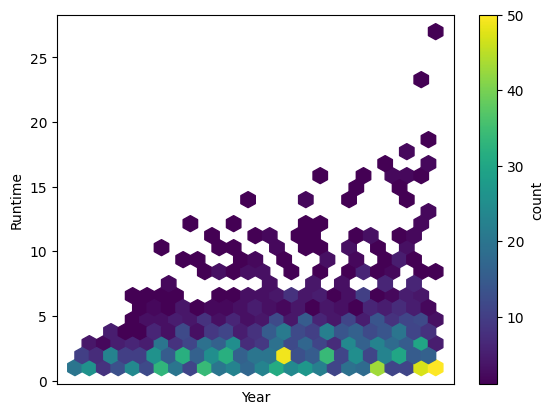

In [160]:
#Probando Graficos...
plt.hexbin(df2["Final Year"], df2["duration"], gridsize=25, mincnt = 1)
plt.colorbar(label="count")
plt.xlabel("Year")
plt.ylabel("Runtime")
plt.show()

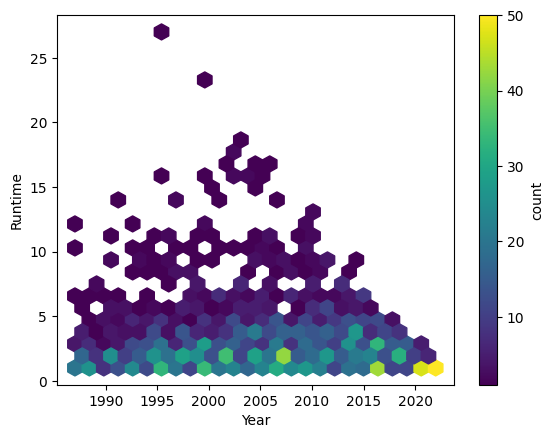

<Figure size 640x480 with 0 Axes>

In [161]:
plt.hexbin(df2["Premiere Year"], df2["duration"], gridsize=25, mincnt = 1)
plt.colorbar(label="count")
plt.xlabel("Year")
plt.ylabel("Runtime")
plt.show()
plt.savefig("añoVSduracion")

In [162]:
#joyplot(df2, by="Premiere Year", column="duration")
#plt.show()
#No logre hacer funcionar el joyplot
df2 = df2.sort_values(by="duration", ascending=False)
df2.head()

,Title,Seasons,Episodes,Country,Premiere Year,Final Year,Original Channel,Technique,duration
127,Arthur,23,246,"Canada, US",1996,2022,PBS Kids,"Traditional, later Flash",27
1757,SpongeBob SquarePants,13,275,US,1999,2021,Nickelodeon,Traditional,23
1493,Pororo the Little Penguin,7,286,South Korea,2003,2021,NaN,CGI,19
1165,Max & Ruby,7,130,Canada,2002,2019,Treehouse TV,Flash,18
1262,Mr. Bean: The Animated Series,5,130,Britain,2002,2019,"ITV, CITV","Traditional (first 3 seasons, later seasons us...",18


In [163]:
#Duracion Serie por pais, algunas series tienen mas de un pais, separar por la coma que los separa y crear otra fila
df2["Country"] = df2["Country"].str.split(",")
df2 = df2.explode("Country")


In [164]:
df2 = df2.sort_values(by="duration", ascending=False)
df2 = df2[~df2["Country"].str.contains(r"\(|\)", regex=True, na=False)]
df2.head()

,Title,Seasons,Episodes,Country,Premiere Year,Final Year,Original Channel,Technique,duration
127,Arthur,23,246,Canada,1996,2022,PBS Kids,"Traditional, later Flash",27
127,Arthur,23,246,US,1996,2022,PBS Kids,"Traditional, later Flash",27
1757,SpongeBob SquarePants,13,275,US,1999,2021,Nickelodeon,Traditional,23
1493,Pororo the Little Penguin,7,286,South Korea,2003,2021,NaN,CGI,19
1165,Max & Ruby,7,130,Canada,2002,2019,Treehouse TV,Flash,18


In [165]:
avg_duration = (
    df2.groupby("Country")["duration"]
    .mean()
    .sort_values()
)

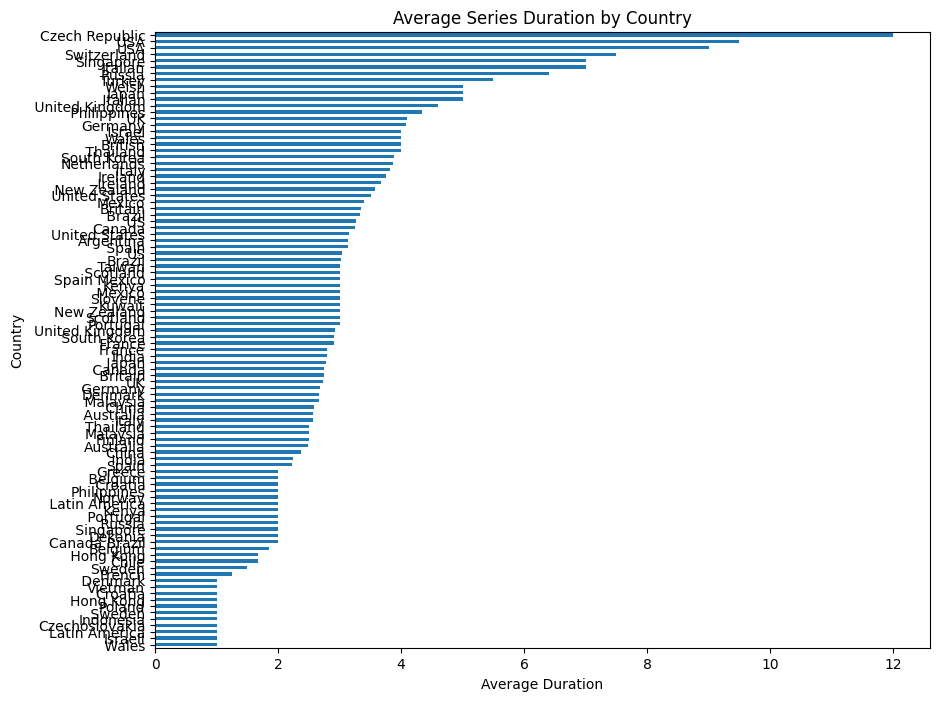

In [166]:
avg_duration.plot(kind="barh", figsize=(10,8))

plt.xlabel("Average Duration")
plt.ylabel("Country")
plt.title("Average Series Duration by Country")

plt.show()

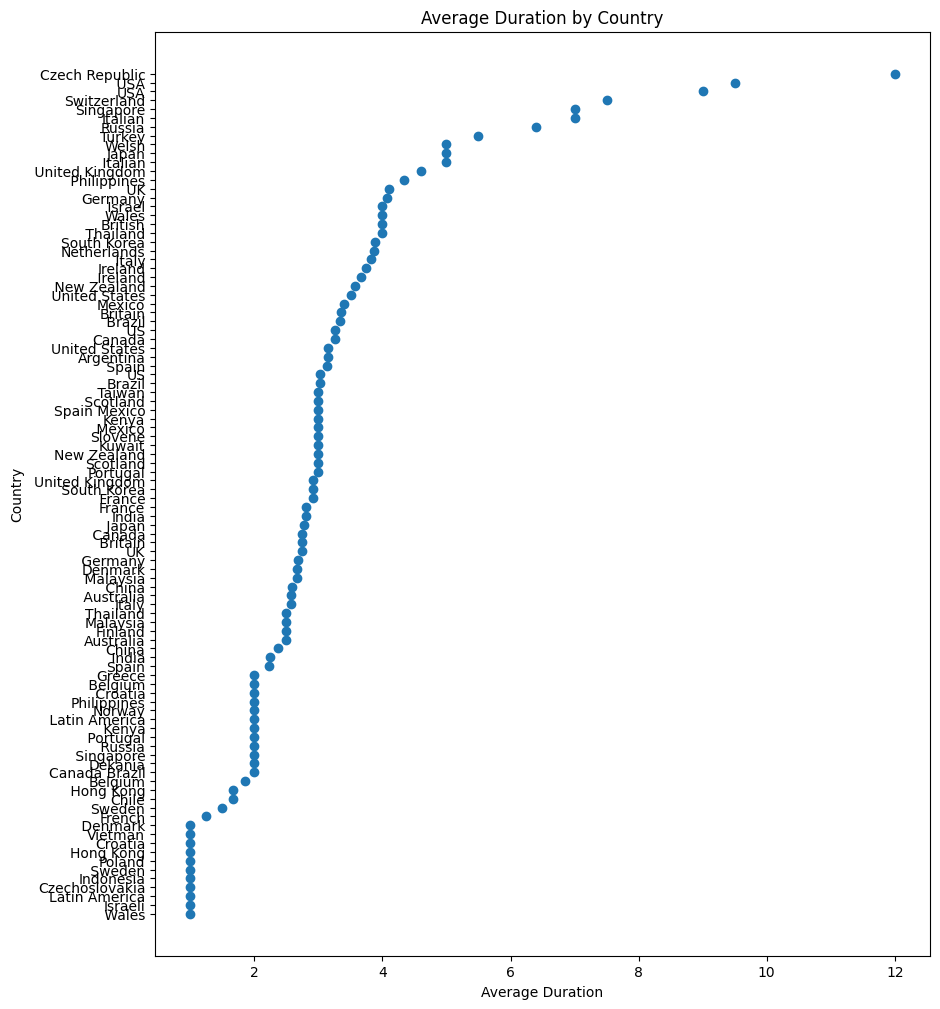

In [167]:
avg = df2.groupby("Country")["duration"].mean().sort_values()

plt.figure(figsize=(10,12))
plt.scatter(avg.values, avg.index)

plt.xlabel("Average Duration")
plt.ylabel("Country")
plt.title("Average Duration by Country")

plt.show()

In [168]:
df2["Country"] = df2["Country"].replace({
    "US": "USA",
    "United States": "USA",
    "United Kingdom": "UK",
    " United Kingdom": "UK",
    " UK": "UK",
    " US": "UK",
    " United States": "USA",
    " USA": "USA",
    "Spain Mexico": "Mexico",
    "Canada Brazil": "Brazil"
})# Esto debiera ser un regex pero lo pense muy tarde....
df2["Country"] = df2["Country"].str.strip()

In [169]:
pio.renderers.default = "browser"
avg = df2.groupby("Country")["duration"].mean().reset_index()
fig = px.treemap(
    avg,
    path=["Country"],
    values="duration",
    color="duration"
)

fig.show()

In [170]:
df2.head()

,Title,Seasons,Episodes,Country,Premiere Year,Final Year,Original Channel,Technique,duration
127,Arthur,23,246,Canada,1996,2022,PBS Kids,"Traditional, later Flash",27
127,Arthur,23,246,UK,1996,2022,PBS Kids,"Traditional, later Flash",27
1757,SpongeBob SquarePants,13,275,USA,1999,2021,Nickelodeon,Traditional,23
1493,Pororo the Little Penguin,7,286,South Korea,2003,2021,NaN,CGI,19
1165,Max & Ruby,7,130,Canada,2002,2019,Treehouse TV,Flash,18


In [174]:
df2["Technique"] = df2["Technique"].str.split(",")
df2 = df2.explode("Technique")
df2["Technique"] = df2["Technique"].str.split("/")
df2 = df2.explode("Technique")
df2["Technique"] = df2["Technique"].str.strip()
df2 = df2[~df2["Technique"].str.contains(r"\(|\)", regex=True, na=False)]


In [175]:
df2["Technique"] = df2["Technique"].replace({
    "ToonBoom Harmony": "Toon Boom Harmony",
    "Toon Boom[1]": "Toon Boom Harmony",
    "later Flash": "Flash",
    "Toon Boom": "Toon Boom Harmony",
    "Toom Boom": "Toon Boom Harmony",
    "Toom Boon": "Toon Boom Harmony",

    "Stop Motion": "Stop Motion",
    "Stop-Motion": "Stop Motion",
    "Stop-motion": "Stop Motion",
    "Stop motion": "Stop Motion",
    
    "Live Action": "Live Action",
    "Live action": "Live Action",
    "Live-Action": "Live Action",
    "Live-action": "Live Action",
    "Live action and Flash": "Live Action"
})# Esto debiera ser un regex pero lo pense muy tarde....

In [176]:
pio.renderers.default = "browser"
avg = df2.groupby("Technique")["duration"].mean().reset_index()
fig = px.treemap(
    avg,
    path=["Technique"],
    values="duration",
    color="duration"
)

fig.show()

In [177]:
avg.head()

,Technique,duration
0,Animation,5.0
1,CGI,3.257048
2,Claymation,7.0
3,Flash,3.107143
4,Live Action,4.22807


In [178]:
print(avg)

           Technique  duration
0          Animation       5.0
1                CGI  3.257048
2         Claymation       7.0
3              Flash  3.107143
4        Live Action   4.22807
5          Rotoscope       1.0
6        Stop Motion  3.469027
7         Syncro-Vox       3.0
8  Toon Boom Harmony       3.0
9        Traditional  2.994514


In [179]:
tech_counts = df2["Technique"].value_counts().reset_index()
tech_counts.columns = ["Technique", "count"]

In [180]:
fig = px.treemap(
    tech_counts,
    path=["Technique"],
    values="count",
    color="count"
)

fig.show()